In [1]:
!pip install lime
!pip install shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283835 sha256=67b8aac06290a853443317d9c6fa8dfadce5f280b6d231188e978408ce3fec3a
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 6.5 MB/s eta 0:00:00


#  Data and Model

In [2]:
# Read the CSV files
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# Take only 200 rows of the data
train_data = train_data.iloc[:200]
test_data = test_data.iloc[:200]

# Map 'satisfied' to 1 and 'neutral or dissatisfied' to 0
train_data = train_data.copy()
train_data['satisfaction'] = train_data['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

test_data['satisfaction'] = test_data['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

# Combine train and test data for preprocessing
combined_data = pd.concat([train_data, test_data], ignore_index=True)

# Drop rows with missing values
combined_data.dropna(inplace=True)

# Encode categorical variables
label_encoder = LabelEncoder()
combined_data['Gender'] = label_encoder.fit_transform(combined_data['Gender'])
combined_data['Customer Type'] = label_encoder.fit_transform(combined_data['Customer Type'])
combined_data['Type of Travel'] = label_encoder.fit_transform(combined_data['Type of Travel'])
combined_data['Class'] = label_encoder.fit_transform(combined_data['Class'])

# Split combined data back into train and test sets
train_data = combined_data.iloc[:200, :]
test_data = combined_data.iloc[200:400, :]

# Separate features and target for training data
X_train = train_data.drop(columns=['satisfaction'])
y_train = train_data['satisfaction']

# Separate features and target for test data
X_test = test_data.drop(columns=['satisfaction'])
y_test = test_data['satisfaction']

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
# Create MLP classifier
nn = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', random_state=42,
                               max_iter=1000, solver='adam', alpha=0.5)
# Train the classifier
nn.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = nn.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.815


# LIME

In [4]:
explainer = lime.lime_tabular.LimeTabularExplainer(X_train_scaled,
                                              feature_names=X_train.columns,
                                              class_names=['neutral/dissatisfied', 'satisfied'],
                                              discretize_continuous=True)

# Choose a sample instance from the test set
sample_idx = 0  # Change this to select a different instance
explanation = explainer.explain_instance(X_test_scaled[sample_idx],
                                         nn.predict_proba,
                                         num_features=len(X_train.columns))

# Show the explanation
explanation.show_in_notebook()

# SHAP

In [5]:
# Create an explainer object
explainer = shap.KernelExplainer(nn.predict_proba, X_train_scaled)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

  0%|          | 0/200 [00:00<?, ?it/s]

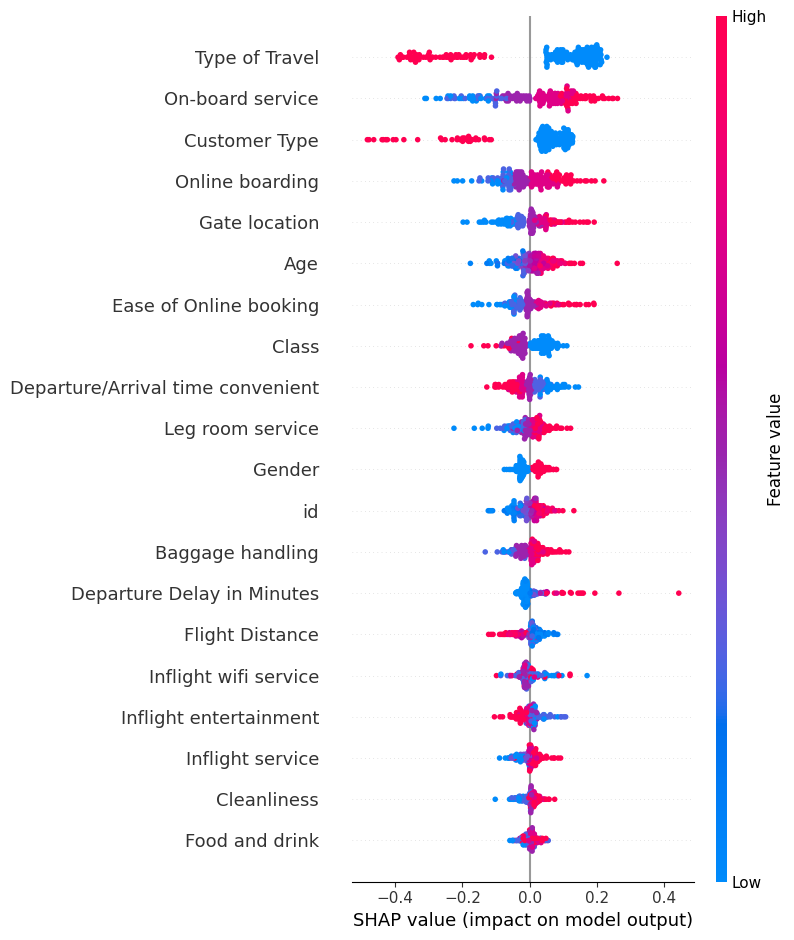

In [6]:
# Visualize the SHAP values
shap.summary_plot(shap_values[:,:,1], X_test_scaled, feature_names=X_train.columns)

# Refrences



*  https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/model_agnostic/Iris%20classification%20with%20scikit-learn.html
* https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
